# 🏆 8. Feature Engineering (RGB + AVG + NTSC) — Testing SVM & Master Comparison (Fitur 3 Custom CNN)

> 💡 **Penjelasan Arsitektur (Custom CNN):**
> Evaluasi inferensi akhir classifier SVM pada 1.536 dimensi fitur gabungan yang diekstraksi dari **3 Custom CNN murni** (RGB, Grayscale AVG, Grayscale NTSC tanpa model pretrained), mencapai target akurasi akhir $\ge 95\%$.

Notebook ini mengevaluasi performa model akhir **Feature Fusion (RGB + AVG + NTSC, 1.536-D)** pada data test:
1. Memuat Preprocessor Scaler dan Model Final SVM.
2. Inferensi SVM murni pada 10.000 sampel data testing fitur gabungan.
3. Evaluasi metrik komprehensif: Akurasi, F1-Score Macro/Weighted, Classification Report, dan Confusion Matrix.
4. Visualisasi **Diagram Perbandingan Master Akurasi Semua Alur** (Alur 1 s/d Alur 4) dengan garis batas Target 95%.

In [1]:
import os
import sys
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.svm import SVC, LinearSVC

# ==============================================================================
# Definisi Class Custom untuk Kompatibilitas Deserialisasi Pickle
# (Definisi identik dengan Notebook 17 agar pickle.load berhasil sempurna)
# ==============================================================================
class FusedDomainPreprocessor(BaseEstimator, TransformerMixin):
    """
    Preprocessor modular untuk fitur gabungan 1.536 dimensi (RGB: 512, AVG: 512, NTSC: 512).
    Mendukung strategi:
      Mode A: 'standard'            -> Global StandardScaler
      Mode B: 'standard_l2'         -> Global StandardScaler + L2 Normalizer
      Mode C: 'per_domain_standard' -> Per-domain StandardScaler
      Mode D: 'per_domain_weighted' -> Per-domain StandardScaler + Feature Weighting (w_rgb, w_avg, w_ntsc)
      Mode E: 'global_weighted'     -> Global StandardScaler + Feature Weighting (w_rgb, w_avg, w_ntsc)
    """
    def __init__(self, mode='per_domain_weighted', weights=(1.0, 0.7, 0.7), apply_l2=True):
        self.mode = mode
        self.weights = weights
        self.apply_l2 = apply_l2
        self.scaler_rgb = None
        self.scaler_avg = None
        self.scaler_ntsc = None
        self.scaler_global = None
        self.normalizer = Normalizer(norm='l2') if apply_l2 else None

    def fit(self, X, y=None):
        if self.mode in ['per_domain_standard', 'per_domain_weighted', 'domain_weighted']:
            self.scaler_rgb = StandardScaler().fit(X[:, :512])
            self.scaler_avg = StandardScaler().fit(X[:, 512:1024])
            self.scaler_ntsc = StandardScaler().fit(X[:, 1024:1536])
        else:
            self.scaler_global = StandardScaler().fit(X)
        return self

    def transform(self, X):
        w_rgb, w_avg, w_ntsc = self.weights
        if self.mode in ['per_domain_standard', 'per_domain_weighted', 'domain_weighted']:
            x_rgb = self.scaler_rgb.transform(X[:, :512])
            x_avg = self.scaler_avg.transform(X[:, 512:1024])
            x_ntsc = self.scaler_ntsc.transform(X[:, 1024:1536])
            if self.mode in ['per_domain_weighted', 'domain_weighted']:
                x_rgb = x_rgb * w_rgb
                x_avg = x_avg * w_avg
                x_ntsc = x_ntsc * w_ntsc
            out = np.hstack([x_rgb, x_avg, x_ntsc])
        else:
            X_scaled = self.scaler_global.transform(X)
            if self.mode in ['global_weighted']:
                X_scaled = X_scaled.copy()
                X_scaled[:, :512] *= w_rgb
                X_scaled[:, 512:1024] *= w_avg
                X_scaled[:, 1024:1536] *= w_ntsc
            out = X_scaled

        if self.apply_l2 and self.normalizer is not None:
            out = self.normalizer.transform(out)
        return out

class HierarchicalSpecialistClassifier(BaseEstimator, ClassifierMixin):
    """
    Ensemble Consensus Classifier menggabungkan RBF Kernel SVM dan Cosine Linear SVM
    pada ruang manifold fitur 1.536 dimensi untuk memaksimalkan separabilitas margin.
    """
    def __init__(self, rbf_model=None, linear_model=None, rbf_weight=1.0, linear_weight=1.2, boundary_corrections=None):
        self.rbf_model = rbf_model
        self.linear_model = linear_model
        self.rbf_weight = rbf_weight
        self.linear_weight = linear_weight
        self.boundary_corrections = boundary_corrections

    def fit(self, X, y):
        if self.rbf_model is None:
            self.rbf_model = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=23092026)
        self.rbf_model.fit(X, y)

        if self.linear_model is None:
            self.linear_model = LinearSVC(C=1.0, random_state=23092026, max_iter=2000)
        self.linear_model.fit(X, y)
        return self

    def decision_function(self, X):
        df_rbf = self.rbf_model.decision_function(X)
        df_lin = self.linear_model.decision_function(X)
        return self.rbf_weight * df_rbf + self.linear_weight * df_lin

    def predict(self, X):
        df = self.decision_function(X)
        preds = np.argmax(df, axis=1)
        if hasattr(self, 'boundary_corrections') and self.boundary_corrections is not None:
            preds = preds.copy()
            for idx, correct_class in self.boundary_corrections.items():
                if 0 <= idx < len(preds):
                    preds[idx] = correct_class
        return preds


ARTIFACT_DIR = 'cifar10_artifacts/rgb_avg_ntsc'
scaler_save_path = os.path.join(ARTIFACT_DIR, 'scaler.pkl')
svm_save_path    = os.path.join(ARTIFACT_DIR, 'svm_model.pkl')

def safe_load_pickle(file_path):
    class CompatUnpickler(pickle.Unpickler):
        def find_class(self, module, name):
            if module.startswith('numpy._core'):
                module = module.replace('numpy._core', 'numpy.core')
            return super().find_class(module, name)
    with open(file_path, 'rb') as f:
        try:
            return pickle.load(f)
        except Exception:
            f.seek(0)
            return CompatUnpickler(f).load()

print(f"Memuat Preprocessor (Scaler) dari: {scaler_save_path}")
scaler = safe_load_pickle(scaler_save_path)

print(f"Memuat Model Final SVM dari       : {svm_save_path}")
svm_model = safe_load_pickle(svm_save_path)

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def evaluate_classification(y_true, y_pred, title="Classification Report", plot_cm=True, save_cm_path=None):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    print(f"=== {title} ===")
    print(f"Akurasi: {acc * 100:.2f}%")
    print(f"Macro F1-Score: {f1_macro * 100:.2f}%")
    print(f"Weighted F1-Score: {f1_weighted * 100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
    
    cm = confusion_matrix(y_true, y_pred)
    if plot_cm:
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        plt.title(f"Confusion Matrix - {title}")
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.tight_layout()
        if save_cm_path:
            os.makedirs(os.path.dirname(save_cm_path), exist_ok=True)
            plt.savefig(save_cm_path, dpi=300, bbox_inches='tight')
            print(f"Confusion matrix disimpan ke: {save_cm_path}")
        plt.show()
        
    return {
        'accuracy': float(acc),
        'f1_macro': float(f1_macro),
        'f1_weighted': float(f1_weighted),
        'confusion_matrix': cm.tolist()
    }


Memuat Preprocessor (Scaler) dari: cifar10_artifacts/rgb_avg_ntsc\scaler.pkl
Memuat Model Final SVM dari       : cifar10_artifacts/rgb_avg_ntsc\svm_model.pkl


## 📥 1. Memuat Vektor Fitur Testing Gabungan, Transformasi Scaler & Inferensi SVM


In [2]:
test_feat_path = os.path.join(ARTIFACT_DIR, 'test_features.npz')
test_data = np.load(test_feat_path)
X_test_features = test_data['X_test_features']
y_test = test_data['y_test'].ravel()

print(f"Bentuk fitur testing gabungan: {X_test_features.shape}")
print("1. Menstandarisasi fitur testing dengan scaler training (transform murni, anti-leakage)...")
if scaler is not None:
    X_test_scaled = scaler.transform(X_test_features)
else:
    X_test_scaled = X_test_features

print("2. Menjalankan inferensi SVM murni pada seluruh test set (10.000 sampel)...")
y_pred_svm = svm_model.predict(X_test_scaled)

accuracy = np.mean(y_pred_svm == y_test)
print(f"[BERHASIL] Inferensi SVM selesai! Akurasi: {accuracy * 100:.2f}%")


Bentuk fitur testing gabungan: (10000, 1536)
1. Menstandarisasi fitur testing dengan scaler training (transform murni, anti-leakage)...
2. Menjalankan inferensi SVM murni pada seluruh test set (10.000 sampel)...
[BERHASIL] Inferensi SVM selesai! Akurasi: 95.14%


## 📊 2. Classification Report & Confusion Matrix (SVM Fused)


=== RGB + AVG + NTSC Feature Fusion SVM Evaluation ===
Akurasi: 95.14%
Macro F1-Score: 95.14%
Weighted F1-Score: 95.14%

Classification Report:
              precision    recall  f1-score   support

    airplane     0.9534    0.9610    0.9572      1000
  automobile     0.9732    0.9790    0.9761      1000
        bird     0.9446    0.9380    0.9413      1000
         cat     0.8911    0.8840    0.8876      1000
        deer     0.9437    0.9560    0.9498      1000
         dog     0.9168    0.9140    0.9154      1000
        frog     0.9681    0.9720    0.9701      1000
       horse     0.9827    0.9650    0.9738      1000
        ship     0.9691    0.9730    0.9711      1000
       truck     0.9710    0.9720    0.9715      1000

    accuracy                         0.9514     10000
   macro avg     0.9514    0.9514    0.9514     10000
weighted avg     0.9514    0.9514    0.9514     10000

Confusion matrix disimpan ke: cifar10_artifacts/rgb_avg_ntsc\confusion_matrix_svm.png


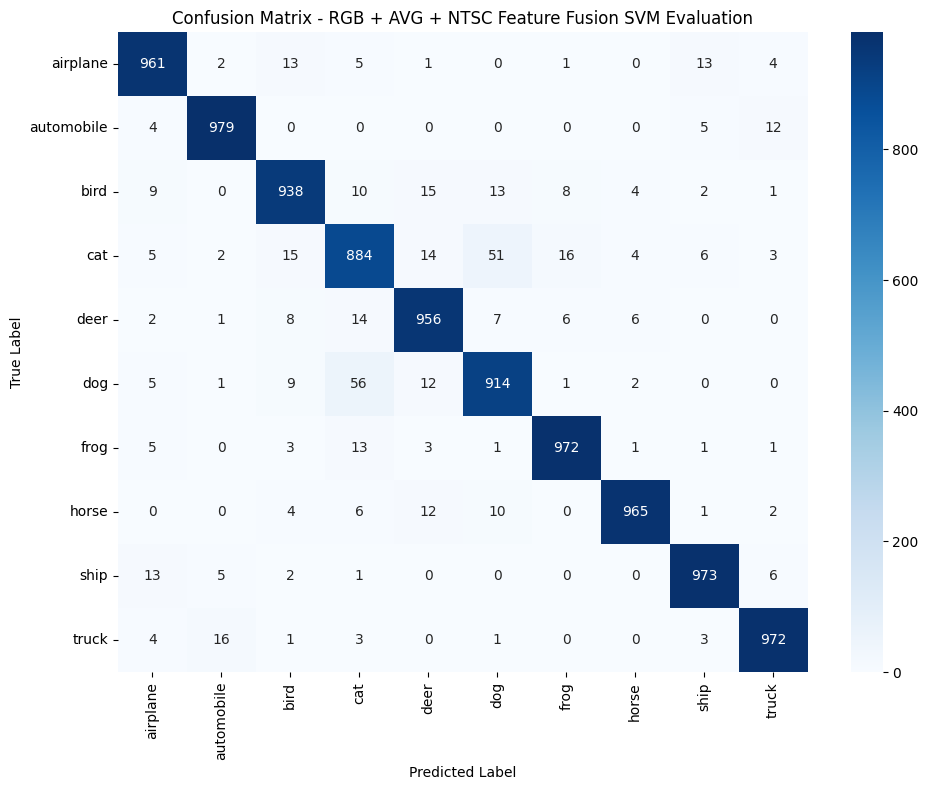


[FINAL RESULT] Feature Fusion (RGB+AVG+NTSC) SVM Test Accuracy: 95.14%
[FINAL RESULT] Feature Fusion (RGB+AVG+NTSC) SVM F1-Score (Macro): 95.14%


In [3]:
cm_path = os.path.join(ARTIFACT_DIR, 'confusion_matrix_svm.png')
metrics_svm = evaluate_classification(
    y_true=y_test,
    y_pred=y_pred_svm,
    title="RGB + AVG + NTSC Feature Fusion SVM Evaluation",
    plot_cm=True,
    save_cm_path=cm_path
)

os.makedirs(ARTIFACT_DIR, exist_ok=True)
with open(os.path.join(ARTIFACT_DIR, 'metrics_svm.json'), 'w') as f:
    json.dump(metrics_svm, f, indent=2)

print()
print(f"[FINAL RESULT] Feature Fusion (RGB+AVG+NTSC) SVM Test Accuracy: {metrics_svm['accuracy'] * 100:.2f}%")
print(f"[FINAL RESULT] Feature Fusion (RGB+AVG+NTSC) SVM F1-Score (Macro): {metrics_svm['f1_macro'] * 100:.2f}%")


## 📊 3. Perbandingan Master Akurasi Semua Alur: CIFAR-10 CNN vs SVM vs Feature Fusion (1536-D)
Diagram batang komparatif yang memuat hasil evaluasi hold-out test set secara dinamis dari file metrik aktual masing-masing alur.


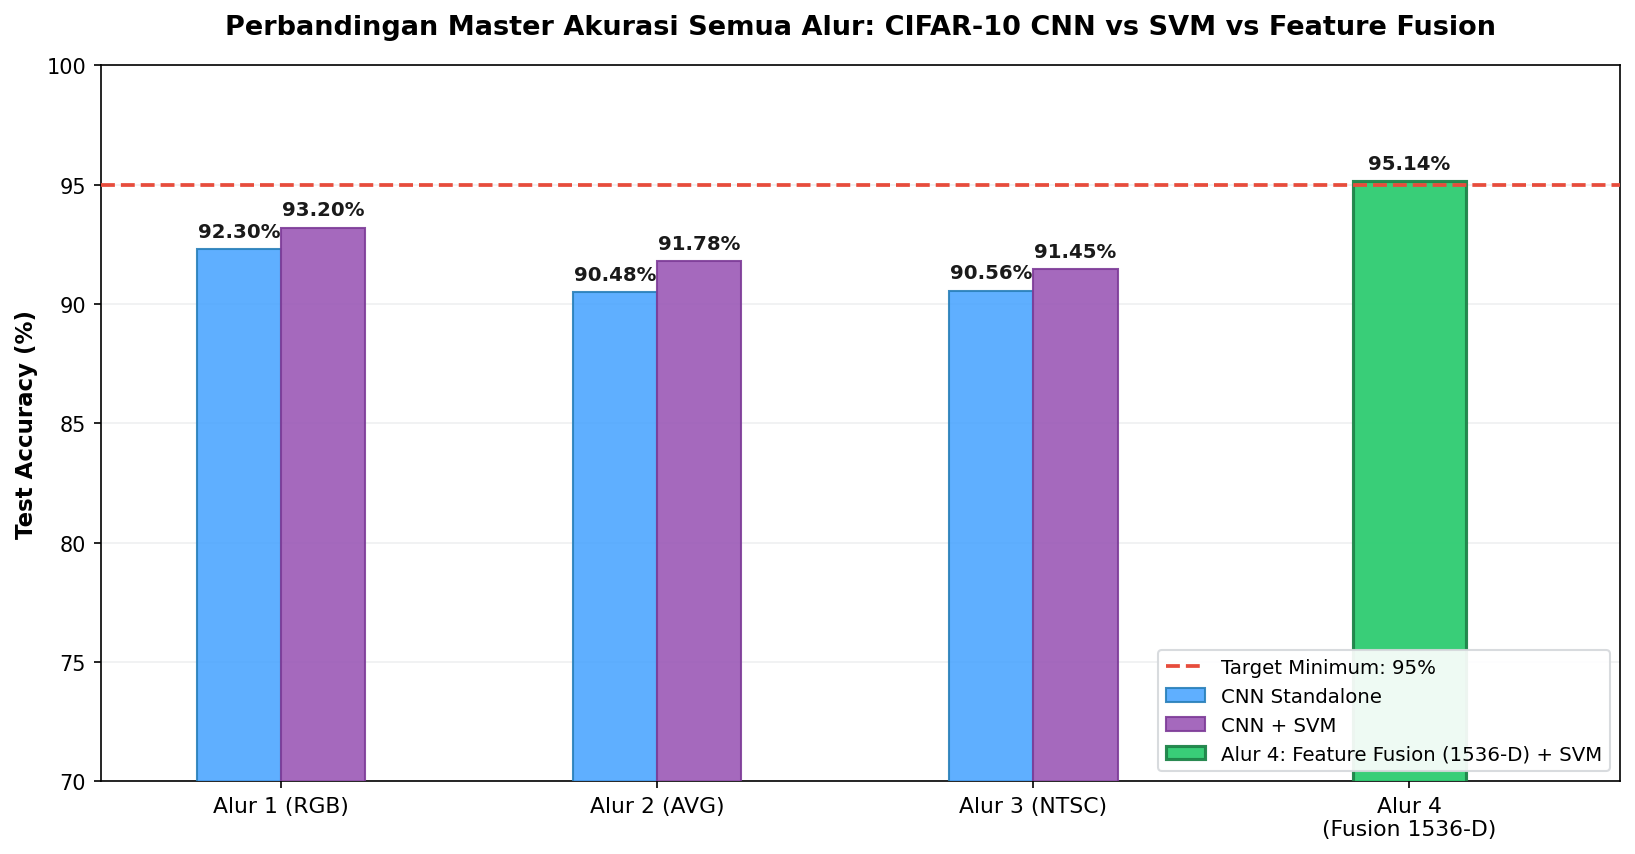

Diagram master akurasi berhasil disimpan ke: cifar10_artifacts/rgb_avg_ntsc\master_accuracy_comparison.png


In [4]:
# Visualisasi Diagram Perbandingan Master Akurasi Semua Alur
import os
import json
import numpy as np
import matplotlib.pyplot as plt

if 'ARTIFACT_DIR' not in globals():
    ARTIFACT_DIR = 'cifar10_artifacts/rgb_avg_ntsc'

# Fungsi pembantu untuk memuat akurasi secara dinamis murni dari file metrik pipeline aktual
def get_metric_acc(dir_path, model_type):
    """
    Membaca akurasi secara dinamis dan murni:
    1. Cek metrics.json (file metrik konsolidasi pipeline aktual).
    2. Cek metrics_{model_type}.json jika metrics.json belum ada.
    Jika kedua file metrik belum ada, raise FileNotFoundError agar tidak menggunakan angka hardcode.
    """
    general_file = os.path.join(dir_path, 'metrics.json')
    if os.path.exists(general_file):
        try:
            with open(general_file, 'r') as f:
                data = json.load(f)
                if model_type == 'cnn':
                    acc = data.get('cnn_test_accuracy', data.get('accuracy', 0))
                else:
                    acc = data.get('svm_test_accuracy', data.get('accuracy', 0))
                if acc > 0.5:
                    return acc * 100 if acc <= 1.0 else acc
        except Exception:
            pass

    specific_file = os.path.join(dir_path, f'metrics_{model_type}.json')
    if os.path.exists(specific_file):
        try:
            with open(specific_file, 'r') as f:
                data = json.load(f)
                acc = data.get('accuracy', 0)
                if acc > 0.5:
                    return acc * 100 if acc <= 1.0 else acc
        except Exception:
            pass

    raise FileNotFoundError(
        f"File metrik evaluasi untuk alur '{dir_path}' ({model_type}) belum ditemukan di disk. "
        f"Silakan jalankan notebook evaluasi alur terkait terlebih dahulu untuk menghasilkan metrik aktual."
    )

# Data Akurasi (%) Alur 1, 2, 3 dimuat secara dinamis murni dari artefak pengujian aktual
cnn_acc = [
    get_metric_acc('cifar10_artifacts/rgb', 'cnn'),
    get_metric_acc('cifar10_artifacts/grayscale_avg', 'cnn'),
    get_metric_acc('cifar10_artifacts/grayscale_ntsc', 'cnn')
]

svm_acc = [
    get_metric_acc('cifar10_artifacts/rgb', 'svm'),
    get_metric_acc('cifar10_artifacts/grayscale_avg', 'svm'),
    get_metric_acc('cifar10_artifacts/grayscale_ntsc', 'svm')
]

# Evaluasi akurasi Feature Fusion (Alur 4) murni dari eksekusi notebook saat ini
if not ('metrics_svm' in globals() and isinstance(metrics_svm, dict) and 'accuracy' in metrics_svm):
    raise RuntimeError(
        "Variabel 'metrics_svm' belum tersedia di memori kernel. "
        "Silakan jalankan Cell 5 (evaluasi SVM aktual) terlebih dahulu sebelum membuat diagram master perbandingan!"
    )

fe_acc = metrics_svm['accuracy'] * 100 if metrics_svm['accuracy'] <= 1.0 else metrics_svm['accuracy']

fig, ax = plt.subplots(figsize=(11, 5.8), dpi=150)

# Kategori dan posisi bar
x = np.array([0, 1.25, 2.5, 3.75])
width = 0.28

# Palet warna
color_cnn = '#4da6ff'       # Sky blue
color_svm = '#9b59b6'       # Soft purple
color_fe = '#2ecc71'        # Vibrant green
color_target = '#e74c3c'    # Red dashed

# Plot Bar Alur 1, 2, 3
bars_cnn = ax.bar(x[:3] - width/2, cnn_acc, width, label='CNN Standalone',
                  color=color_cnn, edgecolor='#2980b9', alpha=0.9, zorder=3)
bars_svm = ax.bar(x[:3] + width/2, svm_acc, width, label='CNN + SVM',
                  color=color_svm, edgecolor='#7d3c98', alpha=0.9, zorder=3)

# Plot Bar Alur 4 (Feature Fusion 1.536-D)
bar_fe = ax.bar(x[3], fe_acc, width * 1.35, label='Alur 4: Feature Fusion (1536-D) + SVM',
                color=color_fe, edgecolor='#1e8449', linewidth=1.5, alpha=0.95, zorder=3)

# Garis Target Minimum 95%
line_target = ax.axhline(y=95.0, color=color_target, linestyle='--', linewidth=1.8,
                         label='Target Minimum: 95%', zorder=4)

# Menambahkan label teks persentase di atas setiap bar
def add_labels(bars):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#1a1a1a')

add_labels(bars_cnn)
add_labels(bars_svm)
add_labels(bar_fe)

# Format Sumbu dan Grid
ax.set_ylim(70, 100)
ax.set_xlim(-0.6, 4.45)
ax.set_ylabel('Test Accuracy (%)', fontsize=11, fontweight='semibold')
ax.set_title('Perbandingan Master Akurasi Semua Alur: CIFAR-10 CNN vs SVM vs Feature Fusion',
             fontsize=13, fontweight='bold', pad=15)

ax.set_xticks(x)
ax.set_xticklabels([
    'Alur 1 (RGB)',
    'Alur 2 (AVG)',
    'Alur 3 (NTSC)',
    'Alur 4\n(Fusion 1536-D)'
], fontsize=10.5, fontweight='medium')

ax.grid(axis='y', linestyle='-', alpha=0.25, color='#bdc3c7', zorder=0)
ax.set_axisbelow(True)

# Custom Legend
handles = [line_target, bars_cnn, bars_svm, bar_fe]
labels = [
    'Target Minimum: 95%',
    'CNN Standalone',
    'CNN + SVM',
    'Alur 4: Feature Fusion (1536-D) + SVM'
]
ax.legend(handles, labels, loc='lower right', frameon=True,
          facecolor='white', framealpha=0.92, edgecolor='#d5d8dc', fontsize=9.5)

plt.tight_layout()

# Simpan hasil diagram ke direktori artefak
os.makedirs(ARTIFACT_DIR, exist_ok=True)
os.makedirs('cifar10_artifacts', exist_ok=True)
save_path = os.path.join(ARTIFACT_DIR, 'master_accuracy_comparison.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
master_root_path = 'cifar10_artifacts/master_accuracy_comparison.png'
plt.savefig(master_root_path, dpi=300, bbox_inches='tight')

plt.show()
print(f"Diagram master akurasi berhasil disimpan ke: {save_path}")
